Using device: cuda

--- Running Scenarios for Seed 42 ---


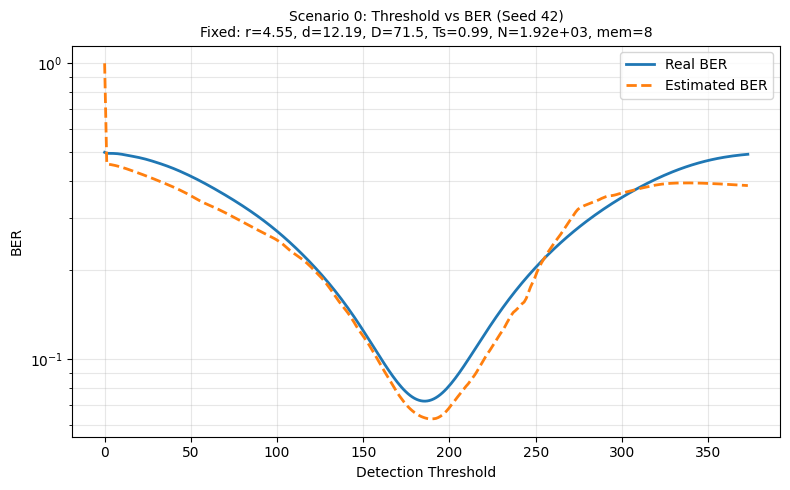

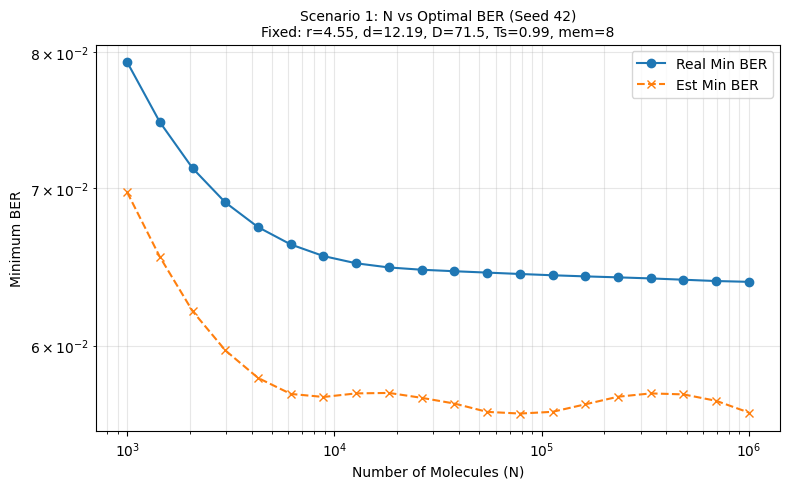

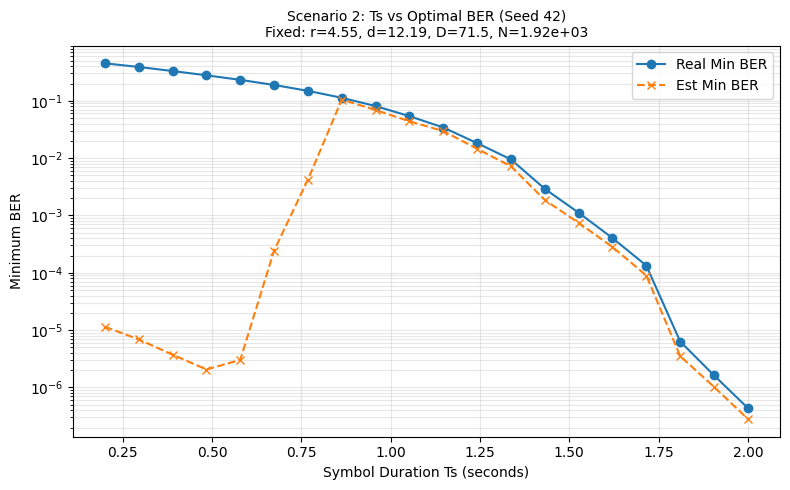

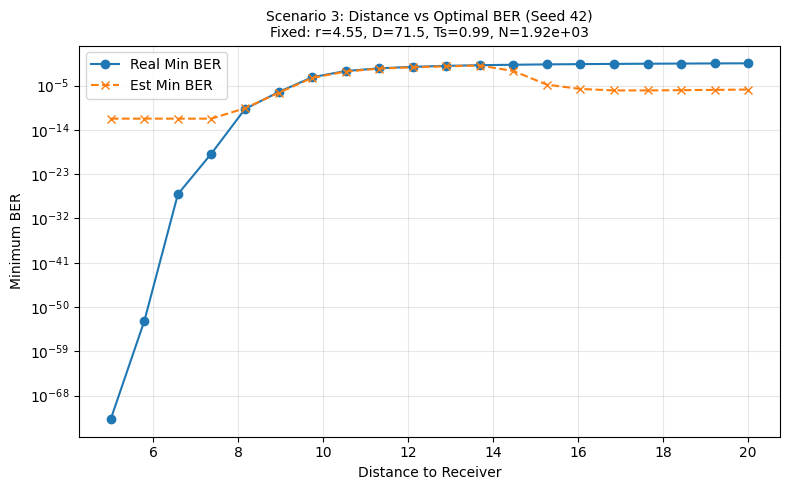


--- Running Scenarios for Seed 100 ---


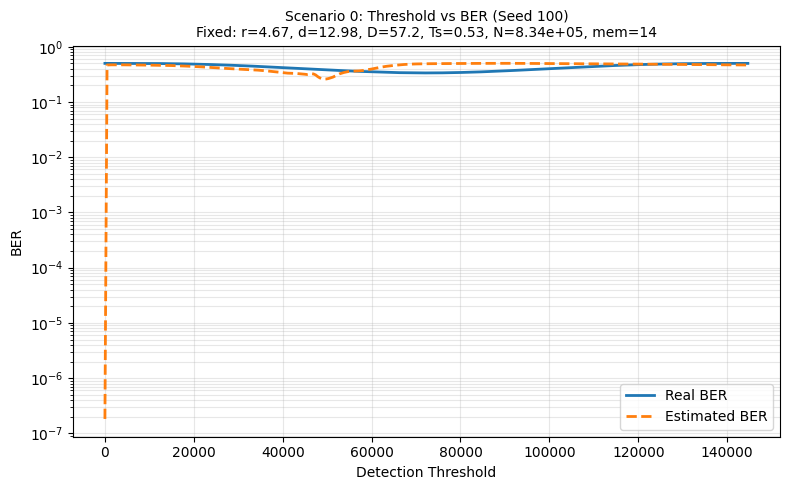

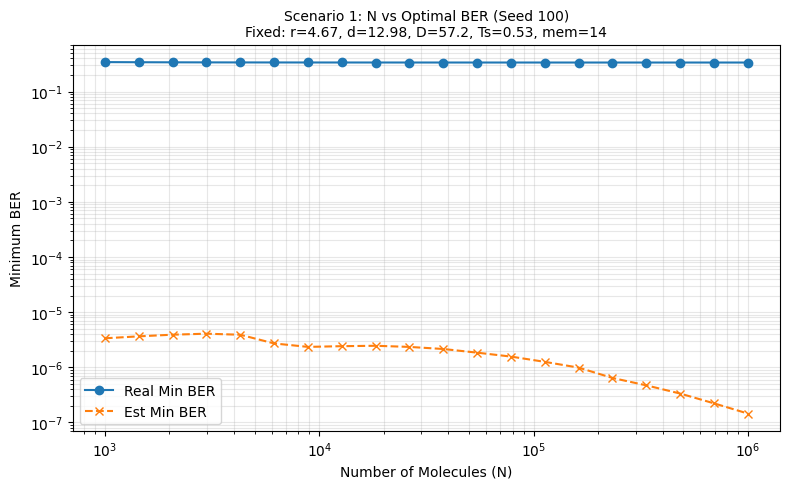

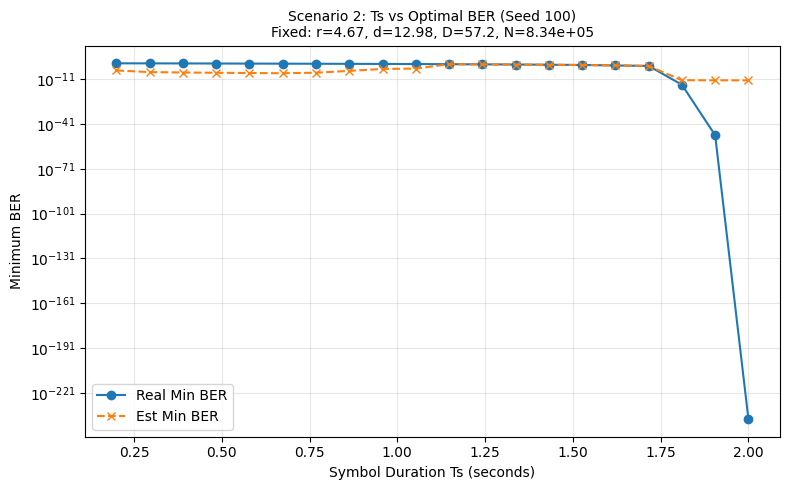

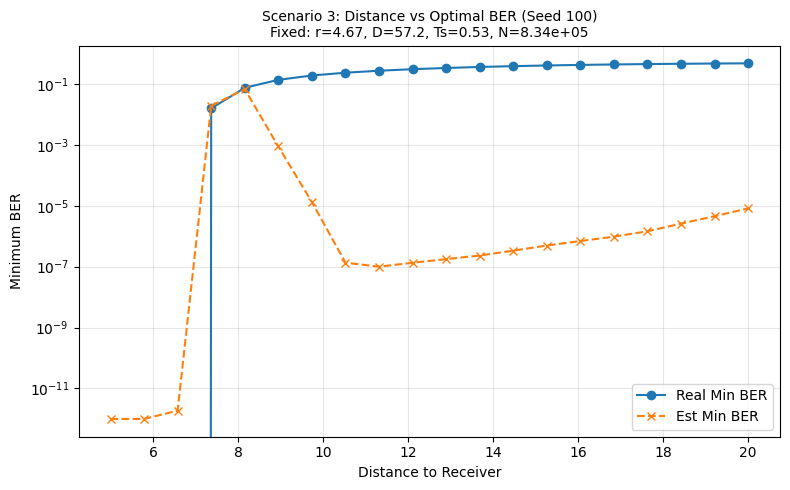

In [1]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_multiscale_rescnn_firstflag_posemb_selfattn_best_stable_large.pth"
SCALER_PATH = "ber_multiscale_rescnn_firstflag_posemb_selfattn_scalers_large.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 3   # increase this if you want larger memory, e.g. 11, 12
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))

def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P

def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))

def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row

# =========================
# Case Generators
# =========================
def generate_physical_case(rng, min_mem_len=10, max_mem_len=14, arrival_coverage=0.70, max_tries=5000):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        case = {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }
        return case

    raise RuntimeError(
        f"Could not generate a physical case with mem_len >= {min_mem_len} "
        f"after {max_tries} tries. Lower PHYSICS_MIN_MEM_LEN or raise max_tries."
    )

def compute_case_from_params(radius, distance, diff, Ts, N, max_mem_len=14, arrival_coverage=0.70):
    f_inf = radius / (radius + distance)
    target = arrival_coverage * f_inf

    cumsum, k = 0.0, 0
    while k < max_mem_len:
        pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
            radius, distance, diff, k * Ts
        )
        cumsum += pk
        k += 1
        if cumsum >= target:
            break

    P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
    P_main = P_ext[:k]
    P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

    P_scaled = P_main * N
    variances = N * P_main * (1.0 - P_main)

    return {
        "radius": radius,
        "distance": distance,
        "diffusion": diff,
        "Ts": Ts,
        "N": N,
        "mem_len": k,
        "P": P_main,
        "P_scaled": P_scaled,
        "variances": variances,
        "P_mem_len_extra": P_extra,
        "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
    }

def get_minimum_ber_for_case(case, model, scalers, device, n_thresholds=200):
    thr_max = float(np.sum(case["P_scaled"]))
    thresholds = np.linspace(0.0, thr_max, n_thresholds)
    
    real_bers = [
        calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"])
        for thr in thresholds
    ]
    
    sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
    seq, thr_scaled = prepare_inference_features(sweep_df, scalers)
    
    seq_t = torch.from_numpy(seq).to(device)
    thr_t = torch.from_numpy(thr_scaled).to(device)
    
    with torch.no_grad():
        pred_log = model(seq_t, thr_t).cpu().numpy().reshape(-1)
    pred_bers = np.clip(10 ** np.clip(pred_log, -12.0, 0.0), EPS, 1.0)
    
    return np.min(real_bers), np.min(pred_bers)

# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                groups=groups,
                bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            )
            if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)],
            dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, threshold_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(threshold_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, thr_emb):
        gamma_beta = self.net(thr_emb)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)

        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels,
            attn_dim=attn_dim,
            num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

class BERMultiScaleResCNNv2(nn.Module):
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)

        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(32, channels[0], hidden_dim=64)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(32, channels[1], hidden_dim=64)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(32, channels[2], hidden_dim=64)

        self.self_attn = LightSelfAttention1D(
            dim=channels[2],
            num_heads=attn_heads,
            mlp_ratio=2.0,
            dropout=dropout
        ) if use_self_attention else nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = (
            self.pool1.out_dim +
            self.pool2.out_dim +
            self.pool3.out_dim +
            self.poolb.out_dim +
            32
        )

        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1)
        )

    def forward(self, seq, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)
        thr = self.thr_embed(threshold)

        x1 = self.stage1(x)
        x1 = self.film1(x1, thr)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, thr)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, thr)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, thr], dim=1)
        return self.head(fused)

# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)

    return pd.DataFrame(rows)

def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)

    if np.all(X_vars_raw >= 0):
        X_vars_feat = np.log10(X_vars_raw + EPS).astype(np.float32)
        snr_raw = np.log10((X_taps_raw ** 2) / (X_vars_raw + 1e-12) + 1e-12).astype(np.float32)
    else:
        X_vars_feat = X_vars_raw.astype(np.float32)
        snr_raw = np.log10((X_taps_raw ** 2) / (np.abs(X_vars_raw) + 1e-12) + 1e-12).astype(np.float32)

    abs_taps_raw = np.abs(X_taps_raw).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_raw).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack(
        [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
        axis=1
    ).astype(np.float32)

    return seq, thr_scaled

# =========================
# Scenario Plotting Functions
# =========================
def plot_scenario_0_threshold(seed, model, scalers, device):
    """Original Scenario: Fix physics, sweep threshold."""
    rng = np.random.default_rng(seed)
    case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    thr_max = float(np.sum(case["P_scaled"]))
    thresholds = np.linspace(0.0, thr_max, 300)
    
    real_bers = [calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"]) for thr in thresholds]
    
    sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
    seq, thr_scaled = prepare_inference_features(sweep_df, scalers)
    with torch.no_grad():
        pred_log = model(torch.from_numpy(seq).to(device), torch.from_numpy(thr_scaled).to(device)).cpu().numpy().reshape(-1)
    pred_bers = np.clip(10 ** np.clip(pred_log, -12.0, 0.0), EPS, 1.0)
    
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, real_bers, label="Real BER", linewidth=2)
    plt.plot(thresholds, pred_bers, label="Estimated BER", linestyle="--", linewidth=2)
    plt.yscale("log")
    plt.xlabel("Detection Threshold")
    plt.ylabel("BER")
    
    title = (f"Scenario 0: Threshold vs BER (Seed {seed})\n"
             f"Fixed: r={case['radius']:.2f}, d={case['distance']:.2f}, "
             f"D={case['diffusion']:.1f}, Ts={case['Ts']:.2f}, "
             f"N={case['N']:.2e}, mem={case['mem_len']}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_1_N(seed, model, scalers, device):
    """Scenario 1: Fix physics, sweep Number of Molecules (Waterfall curve)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    N_values = np.logspace(3, 6, 20) # Sweep N from 1,000 to 1,000,000
    real_mins, pred_mins = [], []
    
    for n in N_values:
        case = compute_case_from_params(base_case["radius"], base_case["distance"], base_case["diffusion"], base_case["Ts"], n)
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(N_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(N_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Number of Molecules (N)")
    plt.ylabel("Minimum BER")
    
    title = (f"Scenario 1: N vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, d={base_case['distance']:.2f}, "
             f"D={base_case['diffusion']:.1f}, Ts={base_case['Ts']:.2f}, mem={base_case['mem_len']}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_2_Ts(seed, model, scalers, device):
    """Scenario 2: Fix physics, sweep Symbol Duration (ISI Stress Test)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    Ts_values = np.linspace(0.2, 2.0, 20) # Sweep Ts from 0.2s (high ISI) to 2.0s (low ISI)
    real_mins, pred_mins = [], []
    
    for ts in Ts_values:
        case = compute_case_from_params(base_case["radius"], base_case["distance"], base_case["diffusion"], ts, base_case["N"])
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(Ts_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(Ts_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.yscale("log")
    plt.xlabel("Symbol Duration Ts (seconds)")
    plt.ylabel("Minimum BER")
    
    title = (f"Scenario 2: Ts vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, d={base_case['distance']:.2f}, "
             f"D={base_case['diffusion']:.1f}, N={base_case['N']:.2e}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_3_Distance(seed, model, scalers, device):
    """Scenario 3: Fix physics, sweep Distance (Signal Decay)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    dist_values = np.linspace(5.0, 20.0, 20) # Sweep distance
    real_mins, pred_mins = [], []
    
    for d in dist_values:
        case = compute_case_from_params(base_case["radius"], d, base_case["diffusion"], base_case["Ts"], base_case["N"])
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(dist_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(dist_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.yscale("log")
    plt.xlabel("Distance to Receiver")
    plt.ylabel("Minimum BER")
    
    title = (f"Scenario 3: Distance vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, D={base_case['diffusion']:.1f}, "
             f"Ts={base_case['Ts']:.2f}, N={base_case['N']:.2e}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================
# Main Execution
# =========================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Load scalers
    scalers = joblib.load(SCALER_PATH)
    
    # Initialize Model
    model = BERMultiScaleResCNNv2(
        seq_len=scalers["seq_len"],
        threshold_dim=1,
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=scalers.get("uses_self_attention", True),
    ).to(device)
    
    # Load Weights
    state = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state)
    model.eval()

    # Define random seeds to test
    test_seeds = [42, 100]
    
    for seed in test_seeds:
        print(f"\n--- Running Scenarios for Seed {seed} ---")
        plot_scenario_0_threshold(seed, model, scalers, device)
        plot_scenario_1_N(seed, model, scalers, device)
        plot_scenario_2_Ts(seed, model, scalers, device)
        plot_scenario_3_Distance(seed, model, scalers, device)

In [ ]:
## ber_boundedloghalf_globalhmg_finetuned_v3_best

Using device: cuda

--- Running Scenarios for Seed 42 ---


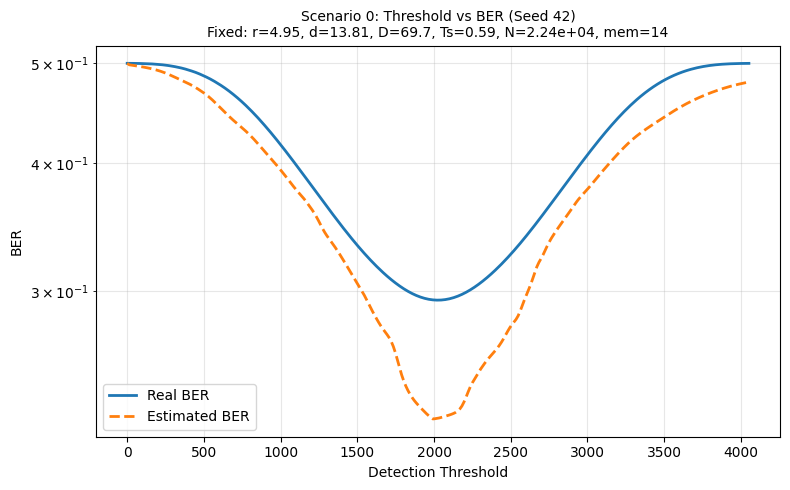

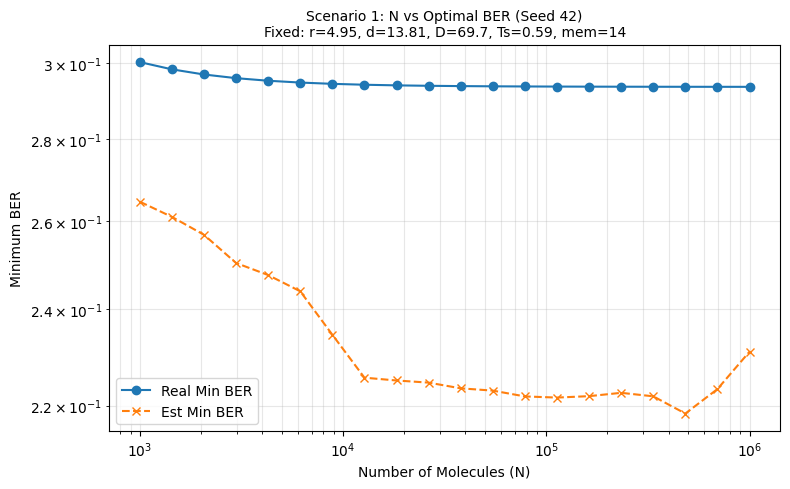

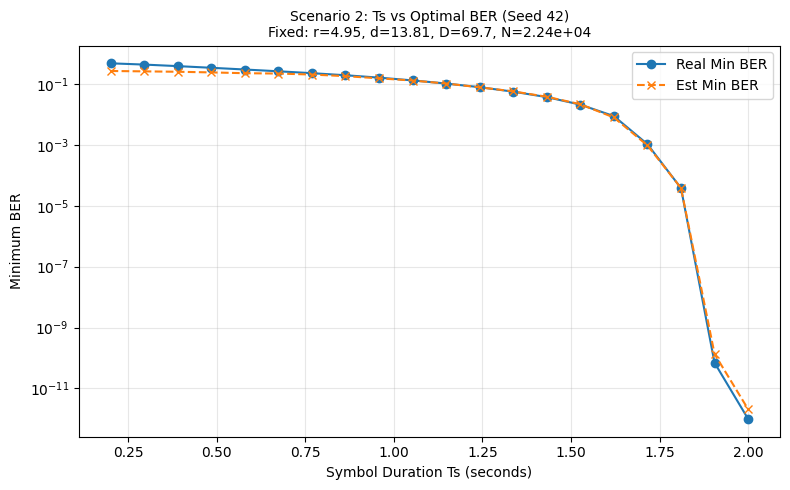

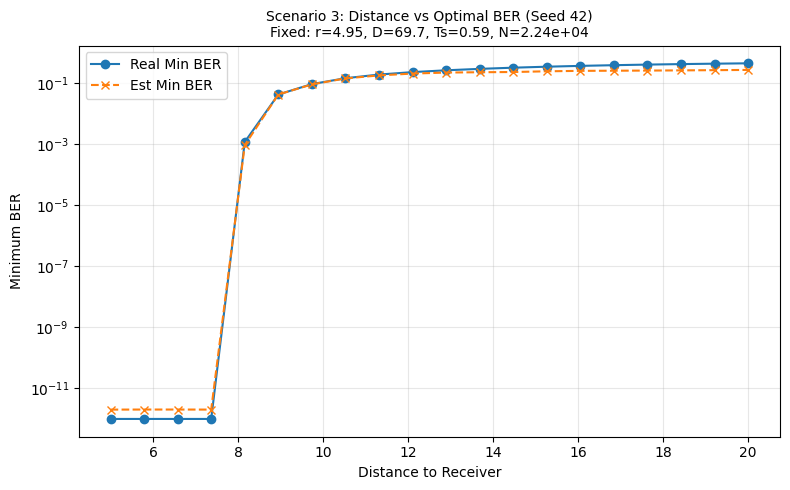


--- Running Scenarios for Seed 100 ---


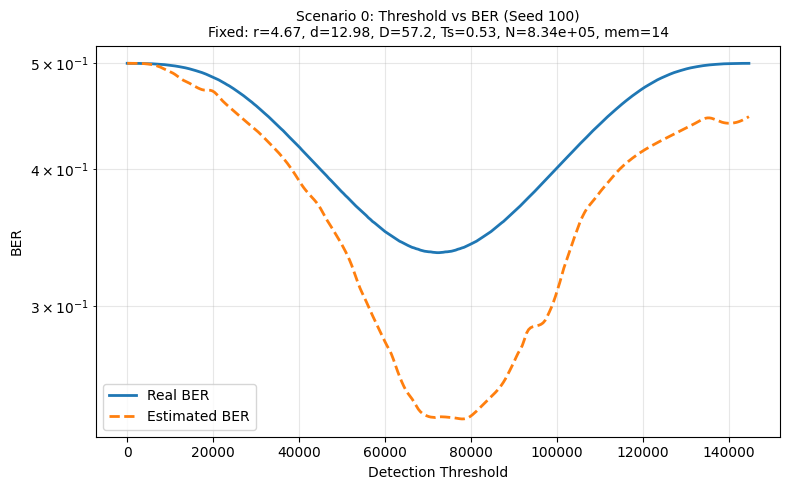

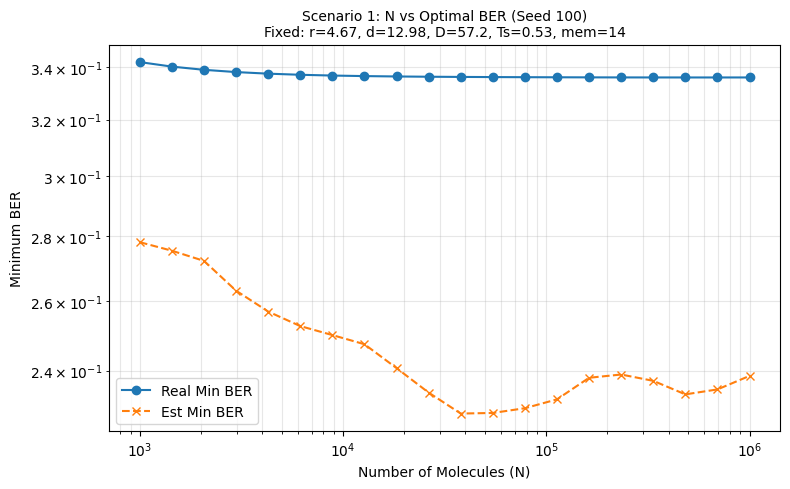

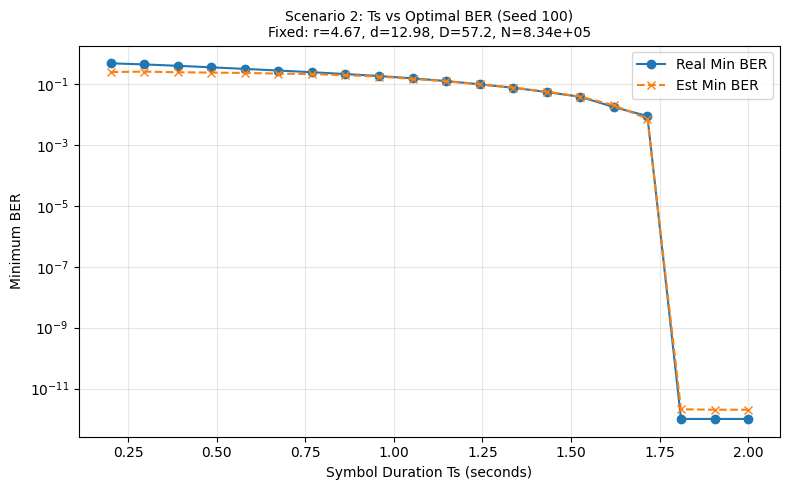

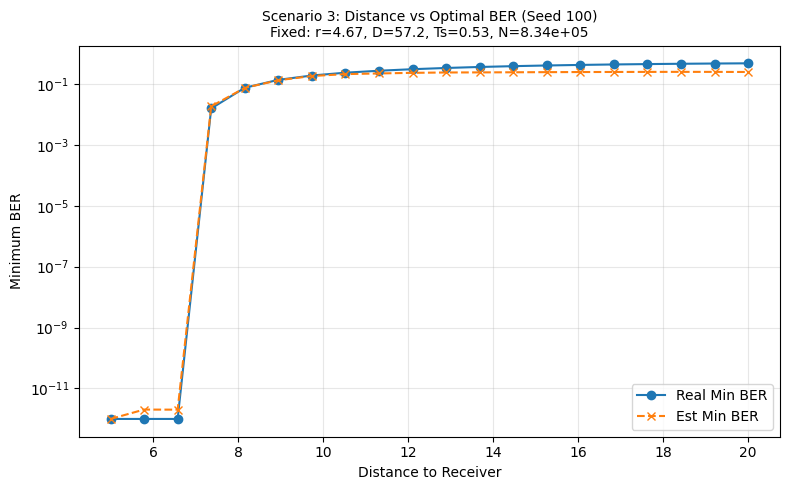

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.special import erfc
from itertools import product as iproduct

EPS = 1e-12

# =========================
# Paths
# =========================
MODEL_PATH = "ber_boundedloghalf_globalhmg_finetuned_v3_best_5M.pth"
SCALER_PATH = "ber_boundedloghalf_globalhmg_scalers_5M.pkl"

# =========================
# Config
# =========================
PHYSICS_MAX_MEM_LEN = 14
PHYSICS_MIN_MEM_LEN = 14
ARRIVAL_COVERAGE = 0.70
N_THRESHOLDS = 500
RANDOM_SEED = 60

# =========================
# Physics helpers
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))

def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P

def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(
            mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0
        )
        pe[zero_std & (c_bit == 0)] = np.where(
            mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0
        )

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc(
            (mu[nz & (c_bit == 1)] - threshold) /
            (std[nz & (c_bit == 1)] * np.sqrt(2))
        )
        pe[nz & (c_bit == 0)] = 0.5 * erfc(
            (threshold - mu[nz & (c_bit == 0)]) /
            (std[nz & (c_bit == 0)] * np.sqrt(2))
        )

    return float(np.mean(pe))

def add_fixed_width_columns(row, values, max_len, prefix):
    for i in range(max_len):
        row[f"{prefix}_{i+1}"] = float(values[i]) if i < len(values) else np.nan
    return row

# =========================
# Case Generators
# =========================
def generate_physical_case(rng, min_mem_len=10, max_mem_len=14, arrival_coverage=0.70, max_tries=5000):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
                radius, distance, diff, k * Ts
            )
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius,
            "distance": distance,
            "diffusion": diff,
            "Ts": Ts,
            "N": N,
            "mem_len": k,
            "P": P_main,
            "P_scaled": P_scaled,
            "variances": variances,
            "P_mem_len_extra": P_extra,
            "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
        }

    raise RuntimeError(f"Could not generate a physical case with mem_len >= {min_mem_len} after {max_tries} tries.")

def compute_case_from_params(radius, distance, diff, Ts, N, max_mem_len=14, arrival_coverage=0.70):
    f_inf = radius / (radius + distance)
    target = arrival_coverage * f_inf

    cumsum, k = 0.0, 0
    while k < max_mem_len:
        pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(
            radius, distance, diff, k * Ts
        )
        cumsum += pk
        k += 1
        if cumsum >= target:
            break

    P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
    P_main = P_ext[:k]
    P_extra = float(P_ext[k]) if k < len(P_ext) else 0.0

    P_scaled = P_main * N
    variances = N * P_main * (1.0 - P_main)

    return {
        "radius": radius,
        "distance": distance,
        "diffusion": diff,
        "Ts": Ts,
        "N": N,
        "mem_len": k,
        "P": P_main,
        "P_scaled": P_scaled,
        "variances": variances,
        "P_mem_len_extra": P_extra,
        "P_mem_len_extra_var": P_extra * (1.0 - P_extra),
    }

# =========================
# Model blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride,
                padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2

        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)

        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False), nn.BatchNorm1d(out_ch))
            if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], dim=1)
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout=dropout, se=se)
        self.down = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(stem_ch, stem_ch, dropout=0.05, se=True)
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads)
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    def __init__(self, seq_len, threshold_dim=1, global_dim=3, stem_ch=32, channels=(64, 96, 128),
                 dropout=0.10, stage_pool_heads=(2, 2, 2, 4), attn_heads=4, pos_emb_dim=8, use_self_attention=True):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch), nn.GELU()
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch), nn.GELU()
        )

        fusion_in = stem_ch * 4
        self.thr_embed = nn.Sequential(nn.Linear(threshold_dim, 32), nn.GELU(), nn.Linear(32, 32), nn.GELU())
        self.global_embed = nn.Sequential(nn.Linear(global_dim, 64), nn.GELU(), nn.Linear(64, 64), nn.GELU())

        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(fusion_in, channels[0], dropout=dropout, se=True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout=dropout, se=True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout=dropout, se=True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        self.self_attn = LightSelfAttention1D(dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout) if use_self_attention else nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
            MultiScaleResidualBlock(channels[2], channels[2], dropout=dropout, se=True),
        )

        self.pool1 = StagePooling(channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64)
        self.pool2 = StagePooling(channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64)
        self.pool3 = StagePooling(channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64)
        self.poolb = StagePooling(channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128)

        head_in = self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim

        self.head = nn.Sequential(
            nn.Linear(head_in, 512), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.15),
            nn.Linear(256, 128), nn.GELU(), nn.Linear(128, 1)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(torch.tensor(0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype))
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :]

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Build model inputs
# =========================
def build_threshold_sweep_dataframe(case, thresholds, scaler_meta):
    tap_cols = scaler_meta["tap_cols"]
    max_len = len(tap_cols)

    rows = []
    for thr in thresholds:
        row = {
            "mem_len": case["mem_len"],
            "threshold": float(thr),
            "BER": np.nan,
            "radius": case["radius"],
            "distance": case["distance"],
            "diffusion": case["diffusion"],
            "Ts": case["Ts"],
            "N": case["N"],
            "P_mem_len_extra": case["P_mem_len_extra"],
            "P_mem_len_extra_var": case["P_mem_len_extra_var"],
        }
        row = add_fixed_width_columns(row, case["P"], max_len, "tap")
        row = add_fixed_width_columns(row, case["variances"], max_len, "var")
        rows.append(row)
    return pd.DataFrame(rows)

def prepare_inference_features(df, scalers):
    tap_cols = scalers["tap_cols"]
    var_cols = scalers["var_cols"]

    X_taps_raw = df[tap_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].fillna(0.0).to_numpy(dtype=np.float32)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_N = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    X_taps_feat = (X_taps_raw * X_N).astype(np.float32)

    if np.any(X_vars_raw < 0):
        raise ValueError("Variance columns contain negative values.")

    X_vars_feat = X_vars_raw.astype(np.float32)
    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10((X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS).astype(np.float32)

    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    harmonic_side_z_raw = (2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))).astype(np.float32)
    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw).astype(np.float32)

    taps_scaled = scalers["tap_scaler"].transform(X_taps_feat).astype(np.float32)
    vars_scaled = scalers["var_scaler"].transform(X_vars_feat).astype(np.float32)
    abs_scaled = scalers["abs_scaler"].transform(abs_taps_raw).astype(np.float32)
    snr_scaled = scalers["snr_scaler"].transform(snr_raw).astype(np.float32)

    z0_scaled = scalers["z0_scaler"].transform(z0_raw).astype(np.float32)
    z1_scaled = scalers["z1_scaler"].transform(z1_raw).astype(np.float32)
    harmonic_minus_gap_scaled = scalers["harmonic_minus_gap_scaler"].transform(harmonic_minus_gap_raw).astype(np.float32)
    thr_scaled = scalers["thr_scaler"].transform(X_thr).astype(np.float32)

    L = taps_scaled.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    pos_ch = np.tile(pos, (len(df), 1)).astype(np.float32)

    first_flag = np.zeros((len(df), L), dtype=np.float32)
    first_flag[:, 0] = 1.0

    seq = np.stack([taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag], axis=1).astype(np.float32)
    global_feats = np.concatenate([z0_scaled, z1_scaled, harmonic_minus_gap_scaled], axis=1).astype(np.float32)

    return seq, global_feats, thr_scaled

# =========================
# Scenario Plotting Functions
# =========================
def get_minimum_ber_for_case(case, model, scalers, device, n_thresholds=200):
    """Sweeps thresholds for a single case and returns the lowest Real and Predicted BER."""
    thr_max = float(np.sum(case["P_scaled"]))
    thresholds = np.linspace(0.0, thr_max, n_thresholds)
    
    real_bers = [
        calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"])
        for thr in thresholds
    ]
    real_bers = np.clip(real_bers, EPS, 0.5)
    
    sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
    seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)
    
    seq_t = torch.from_numpy(seq).to(device)
    global_t = torch.from_numpy(global_feats).to(device)
    thr_t = torch.from_numpy(thr_scaled).to(device)
    
    with torch.no_grad():
        pred_raw_out = model(seq_t, global_t, thr_t)
        pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    
    pred_bers = np.clip(pred_bers, EPS, 0.5)
    
    return np.min(real_bers), np.min(pred_bers)

def plot_scenario_0_threshold(seed, model, scalers, device):
    """Scenario 0: Fix physics, sweep threshold."""
    rng = np.random.default_rng(seed)
    case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    thr_max = float(np.sum(case["P_scaled"]))
    thresholds = np.linspace(0.0, thr_max, 300)
    
    real_bers = [calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"]) for thr in thresholds]
    real_bers = np.clip(real_bers, EPS, 0.5)
    
    sweep_df = build_threshold_sweep_dataframe(case, thresholds, scalers)
    seq, global_feats, thr_scaled = prepare_inference_features(sweep_df, scalers)
    
    seq_t = torch.from_numpy(seq).to(device)
    global_t = torch.from_numpy(global_feats).to(device)
    thr_t = torch.from_numpy(thr_scaled).to(device)
    
    with torch.no_grad():
        pred_raw_out = model(seq_t, global_t, thr_t)
        pred_bers = model.raw_to_ber(pred_raw_out).cpu().numpy().reshape(-1)
    
    pred_bers = np.clip(pred_bers, EPS, 0.5)
    
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, real_bers, label="Real BER", linewidth=2)
    plt.plot(thresholds, pred_bers, label="Estimated BER", linestyle="--", linewidth=2)
    plt.yscale("log")
    plt.xlabel("Detection Threshold")
    plt.ylabel("BER")
    title = (f"Scenario 0: Threshold vs BER (Seed {seed})\n"
             f"Fixed: r={case['radius']:.2f}, d={case['distance']:.2f}, "
             f"D={case['diffusion']:.1f}, Ts={case['Ts']:.2f}, "
             f"N={case['N']:.2e}, mem={case['mem_len']}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_1_N(seed, model, scalers, device):
    """Scenario 1: Fix physics, sweep Number of Molecules (Waterfall curve)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    N_values = np.logspace(3, 6, 20) 
    real_mins, pred_mins = [], []
    
    for n in N_values:
        case = compute_case_from_params(base_case["radius"], base_case["distance"], base_case["diffusion"], base_case["Ts"], n)
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(N_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(N_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Number of Molecules (N)")
    plt.ylabel("Minimum BER")
    title = (f"Scenario 1: N vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, d={base_case['distance']:.2f}, "
             f"D={base_case['diffusion']:.1f}, Ts={base_case['Ts']:.2f}, mem={base_case['mem_len']}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_2_Ts(seed, model, scalers, device):
    """Scenario 2: Fix physics, sweep Symbol Duration (ISI Stress Test)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    Ts_values = np.linspace(0.2, 2.0, 20) 
    real_mins, pred_mins = [], []
    
    for ts in Ts_values:
        case = compute_case_from_params(base_case["radius"], base_case["distance"], base_case["diffusion"], ts, base_case["N"])
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(Ts_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(Ts_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.yscale("log")
    plt.xlabel("Symbol Duration Ts (seconds)")
    plt.ylabel("Minimum BER")
    title = (f"Scenario 2: Ts vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, d={base_case['distance']:.2f}, "
             f"D={base_case['diffusion']:.1f}, N={base_case['N']:.2e}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_scenario_3_Distance(seed, model, scalers, device):
    """Scenario 3: Fix physics, sweep Distance (Signal Decay)."""
    rng = np.random.default_rng(seed)
    base_case = generate_physical_case(rng, min_mem_len=PHYSICS_MIN_MEM_LEN, max_mem_len=PHYSICS_MAX_MEM_LEN)
    
    dist_values = np.linspace(5.0, 20.0, 20) 
    real_mins, pred_mins = [], []
    
    for d in dist_values:
        case = compute_case_from_params(base_case["radius"], d, base_case["diffusion"], base_case["Ts"], base_case["N"])
        r_min, p_min = get_minimum_ber_for_case(case, model, scalers, device)
        real_mins.append(r_min)
        pred_mins.append(p_min)
        
    plt.figure(figsize=(8, 5))
    plt.plot(dist_values, real_mins, label="Real Min BER", marker='o')
    plt.plot(dist_values, pred_mins, label="Est Min BER", marker='x', linestyle="--")
    plt.yscale("log")
    plt.xlabel("Distance to Receiver")
    plt.ylabel("Minimum BER")
    title = (f"Scenario 3: Distance vs Optimal BER (Seed {seed})\n"
             f"Fixed: r={base_case['radius']:.2f}, D={base_case['diffusion']:.1f}, "
             f"Ts={base_case['Ts']:.2f}, N={base_case['N']:.2e}")
    plt.title(title, fontsize=10)
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

# =========================
# Main Execution
# =========================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Load scalers
    scalers = joblib.load(SCALER_PATH)
    
    # Initialize Model
    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=scalers["seq_len"],
        threshold_dim=1,
        global_dim=scalers.get("global_dim", 3),
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=scalers.get("pos_emb_dim", 8),
        use_self_attention=scalers.get("uses_self_attention", True),
    ).to(device)
    
    # Load Weights
    state = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state)
    model.eval()

    # Define random seeds to test
    test_seeds = [42, 100]
    
    for seed in test_seeds:
        print(f"\n--- Running Scenarios for Seed {seed} ---")
        plot_scenario_0_threshold(seed, model, scalers, device)
        plot_scenario_1_N(seed, model, scalers, device)
        plot_scenario_2_Ts(seed, model, scalers, device)
        plot_scenario_3_Distance(seed, model, scalers, device)